In [1]:
import pandas as pd

In [3]:
data =  pd.read_csv("../data/cleaned_covid_positive_only.csv")

In [4]:
data.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,SURVIVED?
0,2,1,1,1,03/05/2020,-1,1,65,0,0,...,0,1,0,0,0,0,0,3,-1,0
1,2,1,0,0,09/06/2020,1,0,55,-1,1,...,0,0,0,0,0,0,0,3,0,0
2,2,1,0,1,21/06/2020,-1,0,68,-1,1,...,0,1,0,0,0,0,0,3,-1,0
3,2,1,1,0,9999-99-99,0,1,40,0,0,...,0,0,0,0,0,0,0,3,0,1
4,2,1,1,1,9999-99-99,-1,0,64,0,0,...,0,0,0,0,0,0,0,3,-1,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391979 entries, 0 to 391978
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   USMER                 391979 non-null  int64 
 1   MEDICAL_UNIT          391979 non-null  int64 
 2   SEX                   391979 non-null  int64 
 3   PATIENT_TYPE          391979 non-null  int64 
 4   DATE_DIED             391979 non-null  object
 5   INTUBED               391979 non-null  int64 
 6   PNEUMONIA             391979 non-null  int64 
 7   AGE                   391979 non-null  int64 
 8   PREGNANT              391979 non-null  int64 
 9   DIABETES              391979 non-null  int64 
 10  COPD                  391979 non-null  int64 
 11  ASTHMA                391979 non-null  int64 
 12  INMSUPR               391979 non-null  int64 
 13  HIPERTENSION          391979 non-null  int64 
 14  OTHER_DISEASE         391979 non-null  int64 
 15  CARDIOVASCULAR   

In [6]:
# Number of male and female
count_by_sex = {"male": 0, "female": 0}
for _,row in data.iterrows():
    if row["SEX"] == 1:
        count_by_sex["female"] = count_by_sex["female"] + 1
    else:
        count_by_sex["male"] = count_by_sex["male"] + 1

In [7]:
count_by_sex

{'male': 209489, 'female': 182490}

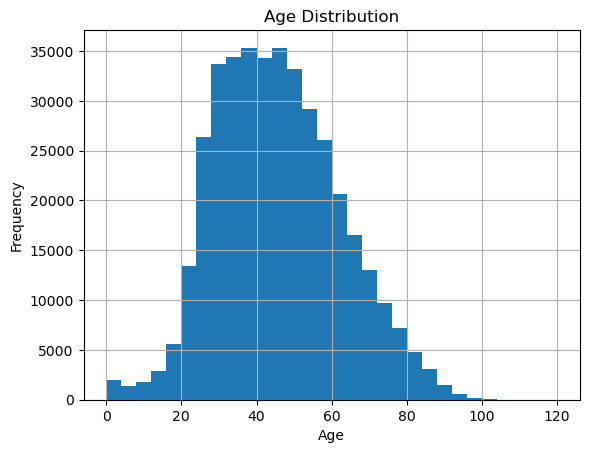

In [8]:
# Age Histogram
import matplotlib.pyplot as plt
data['AGE'].hist(bins=30)

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [9]:
def classify(row):
    if row['INTUBED'] == 1 and row['ICU'] == 1:
        return "Both"
    elif row['INTUBED'] == 1 and row['ICU'] == 0:
        return "Intubated Only"
    elif row['INTUBED'] == 0 and row['ICU'] == 1:
        return "ICU Only"
    else:
        return 

type_of_care = data.apply(classify, axis=1)
counts = type_of_care.value_counts()

In [10]:
counts

Intubated Only    17508
Both               6154
ICU Only           4295
Name: count, dtype: int64

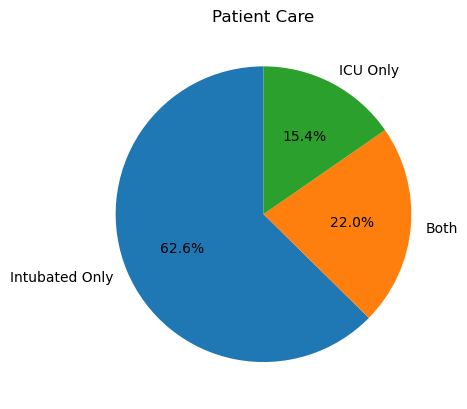

In [13]:
plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Patient Care")
plt.show()

In [63]:
# Correlations
data.corr(numeric_only=True)["PNEUMONIA"].sort_values()

PATIENT_TYPE           -0.674490
SURVIVED?              -0.513428
USMER                  -0.196805
MEDICAL_UNIT           -0.104110
SEX                    -0.092008
PREGNANT               -0.090941
ASTHMA                 -0.016907
CLASIFFICATION_FINAL   -0.007719
TOBACCO                 0.012620
OTHER_DISEASE           0.025118
INMSUPR                 0.036498
CARDIOVASCULAR          0.060060
COPD                    0.066208
OBESITY                 0.073964
RENAL_CHRONIC           0.079490
HIPERTENSION            0.197641
DIABETES                0.217940
AGE                     0.343669
INTUBED                 0.656448
ICU                     0.666872
PNEUMONIA               1.000000
Name: PNEUMONIA, dtype: float64

In [64]:
data.corr(numeric_only=True)["SURVIVED?"].sort_values()

INTUBED                -0.620807
ICU                    -0.534806
PNEUMONIA              -0.513428
AGE                    -0.397807
DIABETES               -0.227944
HIPERTENSION           -0.225954
RENAL_CHRONIC          -0.107772
COPD                   -0.079150
CARDIOVASCULAR         -0.067331
OBESITY                -0.055348
OTHER_DISEASE          -0.041831
INMSUPR                -0.030745
TOBACCO                -0.004810
ASTHMA                  0.024773
CLASIFFICATION_FINAL    0.027681
PREGNANT                0.093010
SEX                     0.093187
USMER                   0.159976
MEDICAL_UNIT            0.170018
PATIENT_TYPE            0.553517
SURVIVED?               1.000000
Name: SURVIVED?, dtype: float64

In [46]:
# Death over time
death_date = {}
for _,row in data.iterrows():
    if row["SURVIVED?"] == 0: # filter for those who did not survive
        date = row["DATE_DIED"]
        if date != "9999-99-99":
            month_year = date[3:5] + date[5:]
            if month_year in death_date:
                death_date[month_year] = death_date[month_year] + 1
            else: 
                death_date[month_year] = 1

death_date = dict(sorted(death_date.items()))

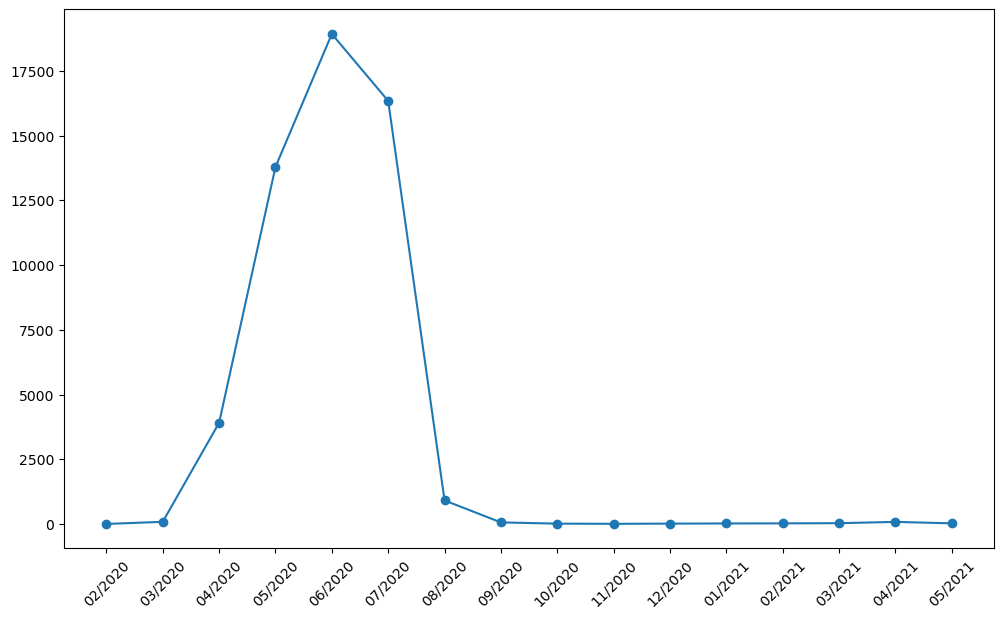

In [51]:
plt.figure(figsize=(12,7))
plt.plot(death_date.keys(), death_date.values(), marker='o')
plt.xticks(rotation=45)  
plt.show()